<a href="https://colab.research.google.com/github/mauleenwaghela/data-science-7-practicals/blob/main/covid_19_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv"

df = pd.read_csv(url)

print("Shape:", df.shape)
df.head()

Shape: (429435, 67)


,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN


In [ ]:
# Keep required columns
covid = df[[
    "location",
    "date",
    "total_cases",
    "new_cases",
    "total_deaths",
    "new_deaths",
    "people_vaccinated"
]]

covid["date"] = pd.to_datetime(covid["date"])

covid.head()

/tmp/ipykernel_3480/4161835767.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  covid["date"] = pd.to_datetime(covid["date"])


,location,date,total_cases,new_cases,total_deaths,new_deaths,people_vaccinated
0,Afghanistan,2020-01-05,0.0,0.0,0.0,0.0,NaN
1,Afghanistan,2020-01-06,0.0,0.0,0.0,0.0,NaN
2,Afghanistan,2020-01-07,0.0,0.0,0.0,0.0,NaN
3,Afghanistan,2020-01-08,0.0,0.0,0.0,0.0,NaN
4,Afghanistan,2020-01-09,0.0,0.0,0.0,0.0,NaN


In [ ]:
india = covid[covid["location"] == "India"]

india.tail()

,location,date,total_cases,new_cases,total_deaths,new_deaths,people_vaccinated
175226,India,2024-08-08,NaN,NaN,NaN,NaN,1.027439e+09
175227,India,2024-08-09,NaN,NaN,NaN,NaN,1.027439e+09
175228,India,2024-08-10,NaN,NaN,NaN,NaN,1.027439e+09
175229,India,2024-08-11,NaN,NaN,NaN,NaN,1.027439e+09
175230,India,2024-08-12,NaN,NaN,NaN,NaN,1.027439e+09


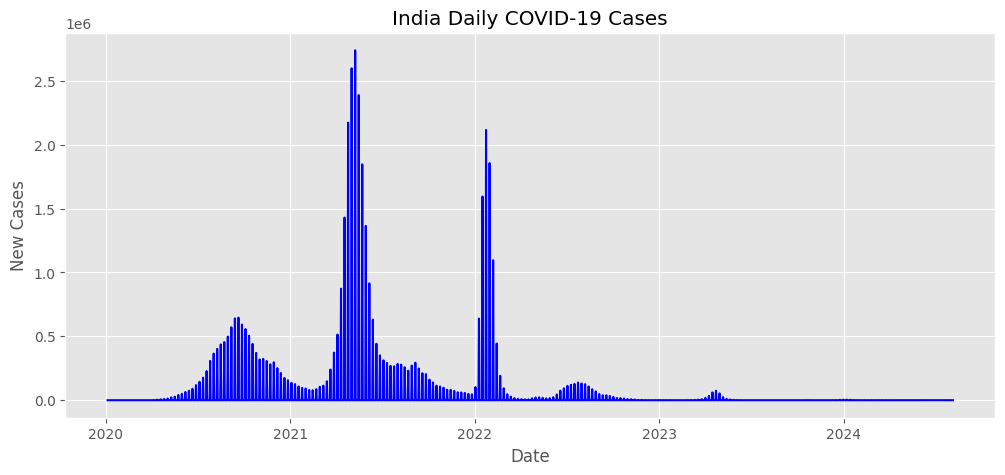

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(india["date"], india["new_cases"], color="blue")

plt.title("India Daily COVID-19 Cases")
plt.xlabel("Date")
plt.ylabel("New Cases")
plt.show()

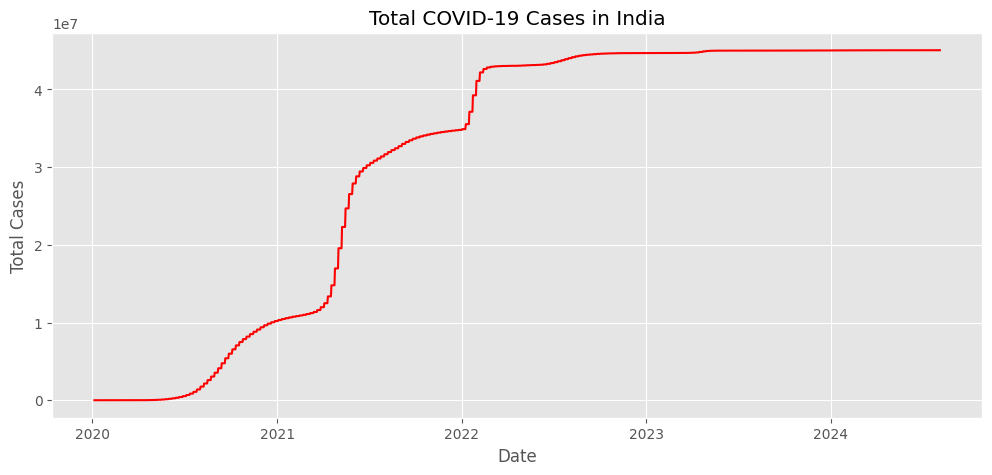

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(india["date"], india["total_cases"], color="red")

plt.title("Total COVID-19 Cases in India")
plt.xlabel("Date")
plt.ylabel("Total Cases")
plt.show()

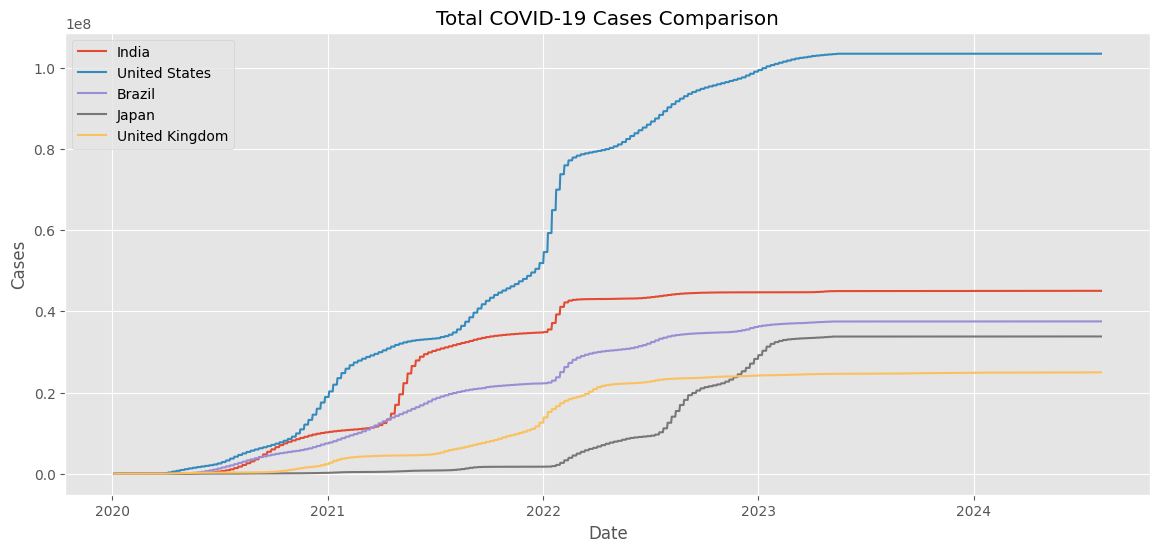

In [ ]:
countries = ["India","United States","Brazil","Japan","United Kingdom"]

compare = covid[covid["location"].isin(countries)]

plt.figure(figsize=(14,6))

for country in countries:
    data = compare[compare["location"] == country]
    plt.plot(data["date"], data["total_cases"], label=country)

plt.legend()
plt.title("Total COVID-19 Cases Comparison")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.show()

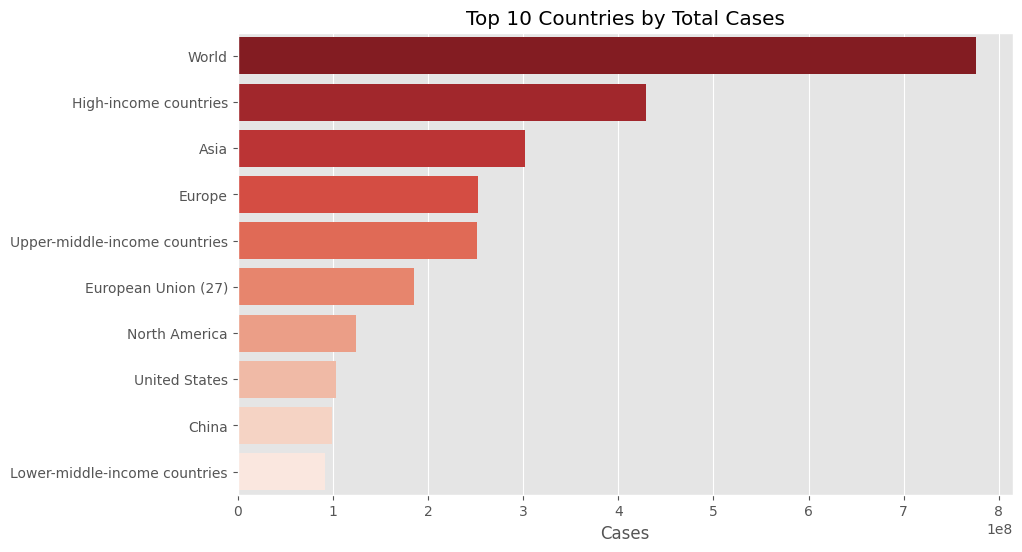

In [ ]:
latest = covid.sort_values("date").groupby("location").last()

top_cases = latest.nlargest(10, "total_cases")

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_cases,
    x="total_cases",
    y=top_cases.index,
    hue=top_cases.index,
    palette="Reds_r",
    legend=False
)

plt.title("Top 10 Countries by Total Cases")
plt.xlabel("Cases")
plt.ylabel("")
plt.show()

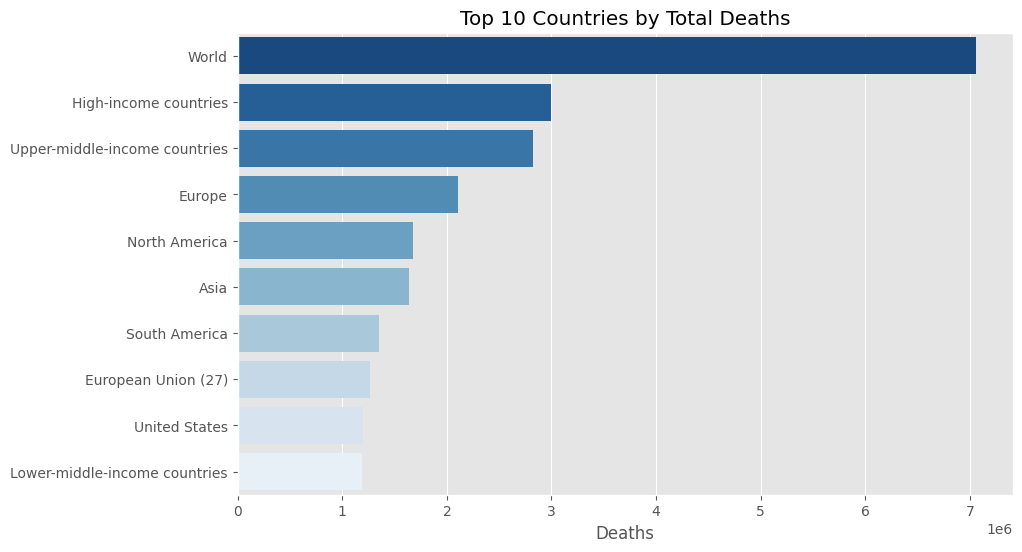

In [ ]:
top_deaths = latest.nlargest(10, "total_deaths")

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_deaths,
    x="total_deaths",
    y=top_deaths.index,
    hue=top_deaths.index,
    palette="Blues_r",
    legend=False
)

plt.title("Top 10 Countries by Total Deaths")
plt.xlabel("Deaths")
plt.ylabel("")
plt.show()

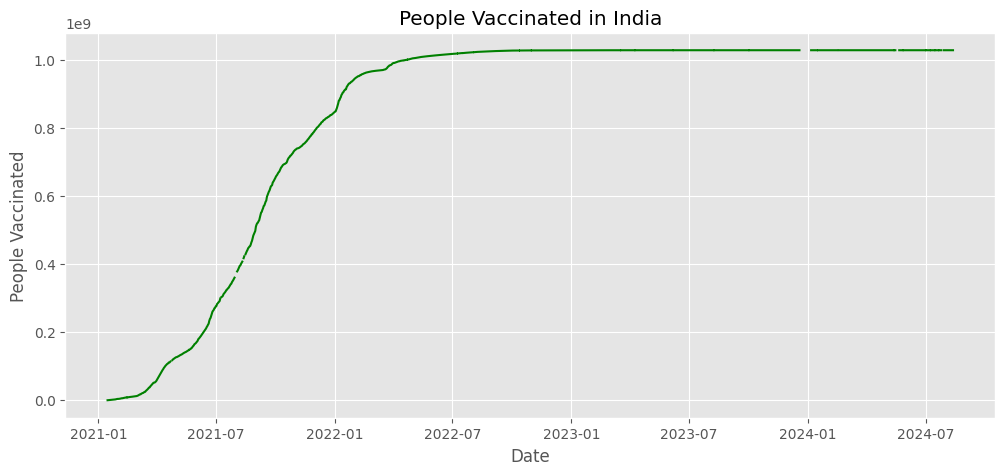

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    india["date"],
    india["people_vaccinated"],
    color="green"
)

plt.title("People Vaccinated in India")
plt.xlabel("Date")
plt.ylabel("People Vaccinated")
plt.show()

In [ ]:
print("Total Cases in India:",
      int(india["total_cases"].max()))

print("Total Deaths in India:",
      int(india["total_deaths"].max()))

print("Highest Daily Cases:",
      int(india["new_cases"].max()))

print("Highest Daily Deaths:",
      int(india["new_deaths"].max()))

Total Cases in India: 45041748
Total Deaths in India: 533623
Highest Daily Cases: 2738957
Highest Daily Deaths: 28982
